In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

# Load dataset
data = load_breast_cancer()

# Create DataFrame
X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(
    data.target,
    name="target"
)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())
display(y.head())

Features shape: (569, 30)
Target shape: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [2]:
print("Dataset information:")
print(X.info())

print("\nMissing values:")
print(X.isnull().sum().sum())

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget names:")
print(data.target_names)

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error

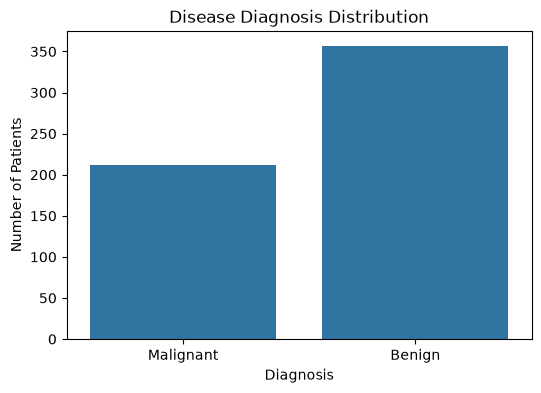

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(x=y)

plt.title("Disease Diagnosis Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Patients")

plt.xticks(
    [0, 1],
    ["Malignant", "Benign"]
)

plt.show()

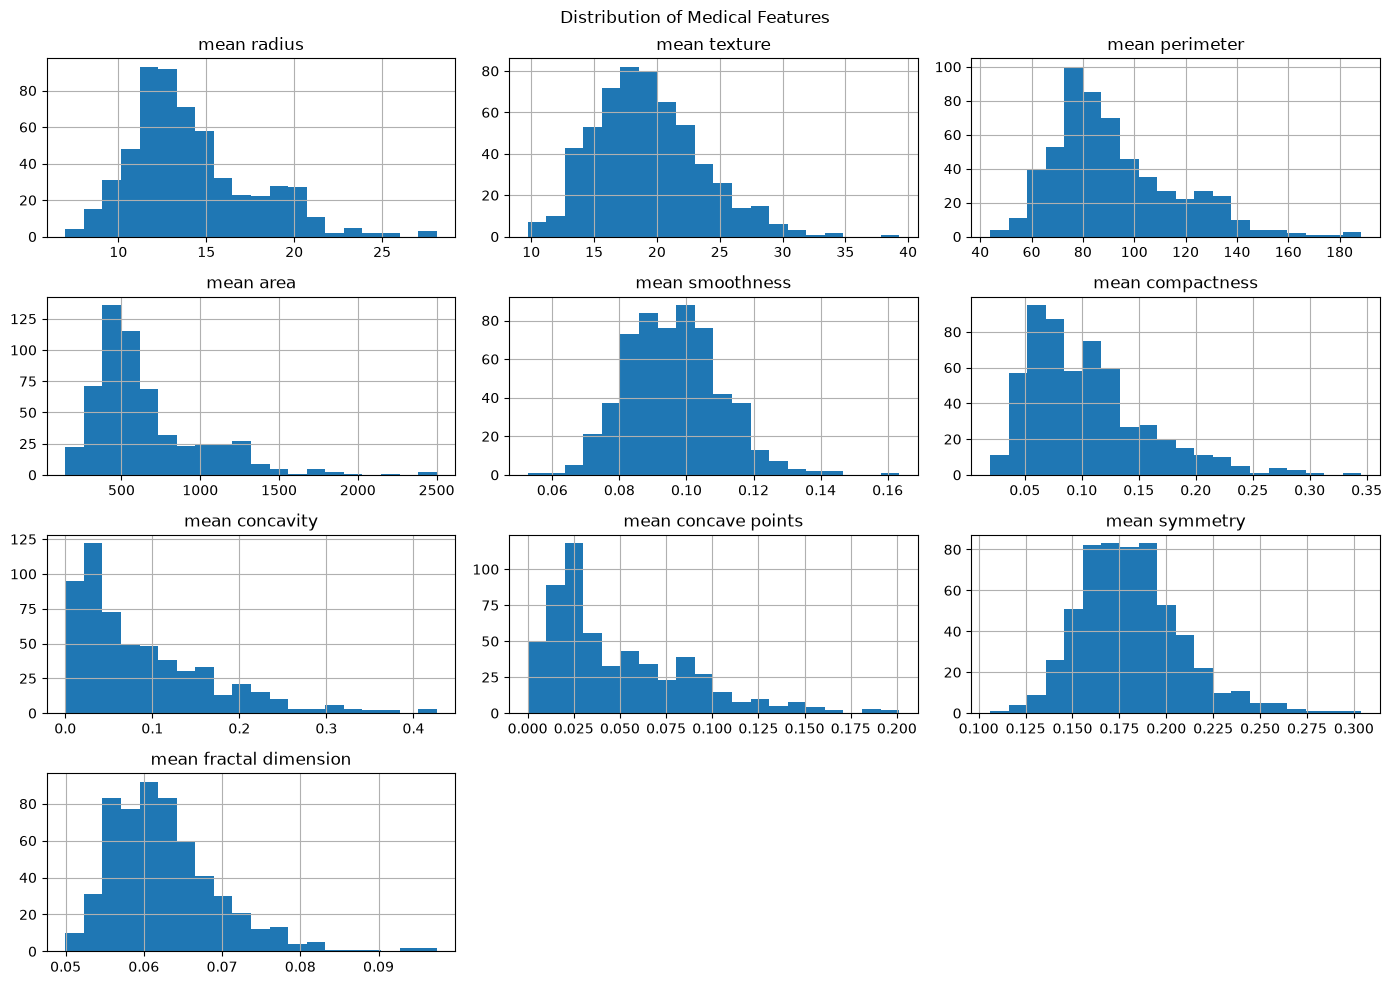

In [4]:
X.iloc[:, :10].hist(
    figsize=(14, 10),
    bins=20
)

plt.suptitle("Distribution of Medical Features")
plt.tight_layout()
plt.show()

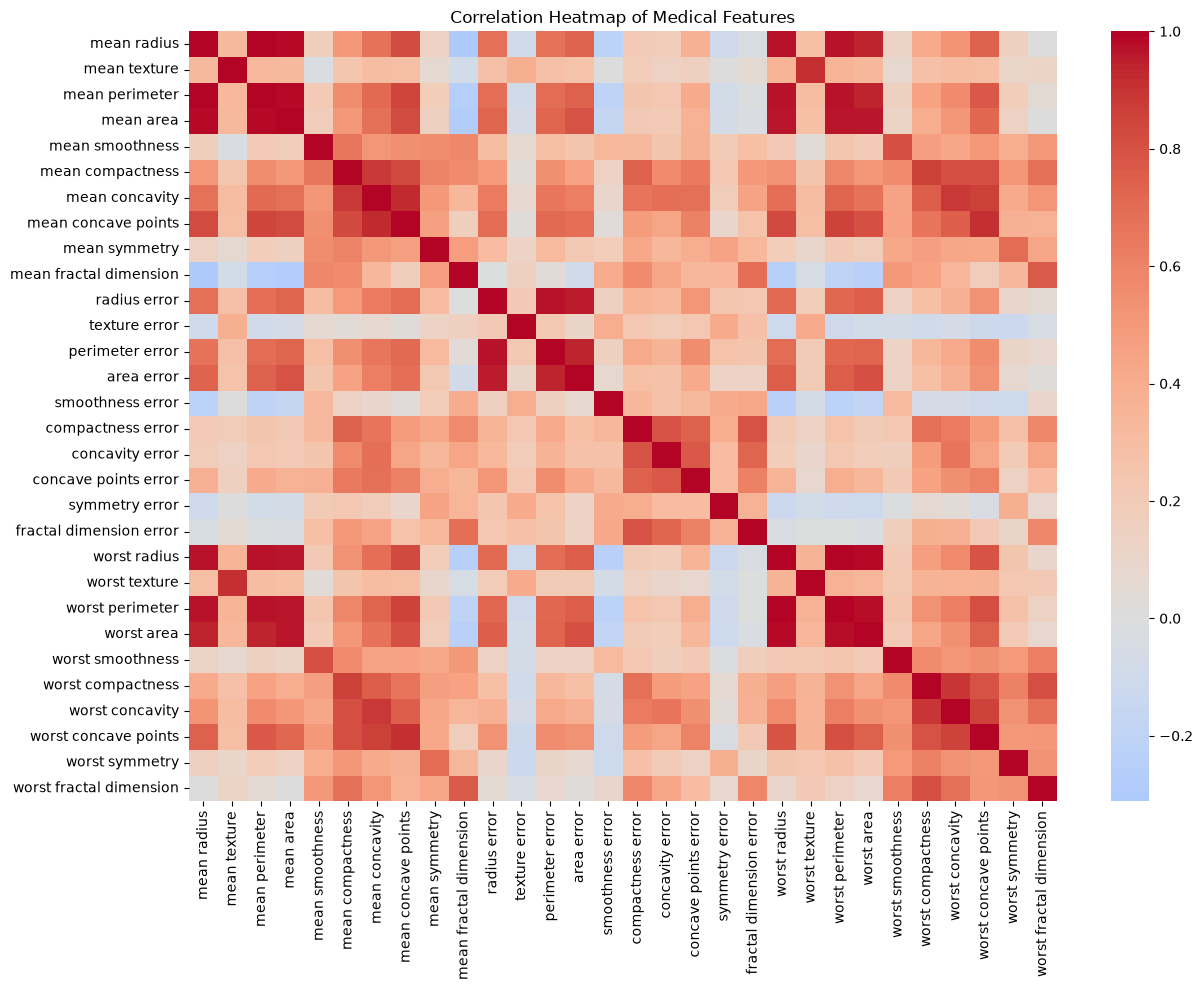

In [5]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    X.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Medical Features")
plt.show()

In [6]:
display(X.describe().T)

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (455, 30)
Testing data: (114, 30)


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully! ✅")

Scaling completed successfully! ✅


In [10]:
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

print("\nFirst 5 scaled rows:")
print(X_train_scaled[:5])

X_train_scaled shape: (455, 30)
X_test_scaled shape: (114, 30)

First 5 scaled rows:
[[-1.07200079e+00 -6.58424598e-01 -1.08808010e+00 -9.39273639e-01
  -1.35939882e-01 -1.00871795e+00 -9.68358632e-01 -1.10203235e+00
   2.81062120e-01 -1.13231479e-01 -7.04860874e-01 -4.40938351e-01
  -7.43948977e-01 -6.29804931e-01  7.48061001e-04 -9.91572979e-01
  -6.93759567e-01 -9.83284458e-01 -5.91579010e-01 -4.28972052e-01
  -1.03409427e+00 -6.23497432e-01 -1.07077336e+00 -8.76534437e-01
  -1.69982346e-01 -1.03883630e+00 -1.07899452e+00 -1.35052668e+00
  -3.52658049e-01 -5.41380026e-01]
 [ 1.74874285e+00  6.65017334e-02  1.75115682e+00  1.74555856e+00
   1.27446827e+00  8.42288215e-01  1.51985232e+00  1.99466430e+00
  -2.93045055e-01 -3.20179716e-01  1.27567198e-01 -3.81382677e-01
   9.40746962e-02  3.17524379e-01  6.39656015e-01  8.73892616e-02
   7.08450758e-01  1.18215034e+00  4.26212305e-01  7.47970186e-02
   1.22834212e+00 -9.28334970e-02  1.18746742e+00  1.10438613e+00
   1.51700092e+00  2.4

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [12]:
logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

svm_model = SVC(
    probability=True,
    random_state=42
)

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [13]:
print("Training Logistic Regression...")
logistic_model.fit(X_train_scaled, y_train)

print("Training SVM...")
svm_model.fit(X_train_scaled, y_train)

print("Training Random Forest...")
random_forest_model.fit(X_train_scaled, y_train)

print("\nAll models trained successfully! ✅")

Training Logistic Regression...
Training SVM...


c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Training Random Forest...

All models trained successfully! ✅


In [14]:
y_pred_logistic = logistic_model.predict(X_test_scaled)
y_pred_svm = svm_model.predict(X_test_scaled)
y_pred_forest = random_forest_model.predict(X_test_scaled)

print("Predictions completed! ✅")

Predictions completed! ✅


In [15]:
y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]
y_prob_forest = random_forest_model.predict_proba(X_test_scaled)[:, 1]

print("Probability predictions completed! ✅")

Probability predictions completed! ✅


In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [17]:
models = {
    "Logistic Regression": (
        y_pred_logistic,
        y_prob_logistic
    ),
    "SVM": (
        y_pred_svm,
        y_prob_svm
    ),
    "Random Forest": (
        y_pred_forest,
        y_prob_forest
    )
}

results = []

for name, (predictions, probabilities) in models.items():

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, probabilities)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111,0.995370
1,SVM,0.982456,0.986111,0.986111,0.986111,0.995040
2,Random Forest,0.956140,0.958904,0.972222,0.965517,0.993221


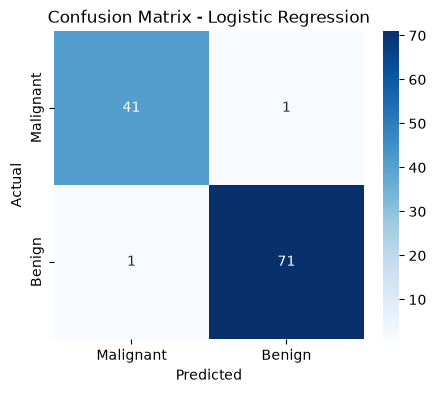

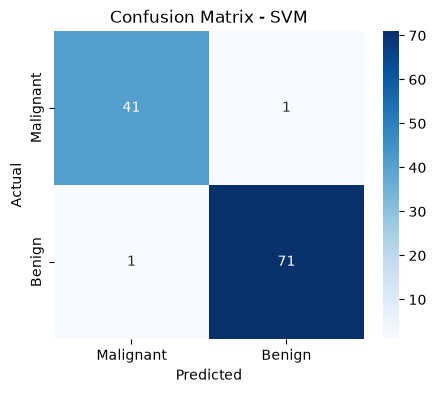

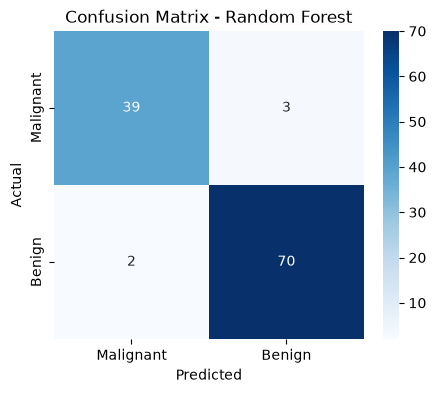

In [18]:
for name, (predictions, probabilities) in models.items():

    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Malignant", "Benign"],
        yticklabels=["Malignant", "Benign"]
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

In [19]:
for name, (predictions, probabilities) in models.items():

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            predictions,
            target_names=["Malignant", "Benign"]
        )
    )


Logistic Regression
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


SVM
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Random Forest
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96

In [20]:
from sklearn.model_selection import GridSearchCV

In [21]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [1000, 2000]
}

In [22]:
grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(grid_search.best_score_)

Best Parameters:
{'C': 0.1, 'max_iter': 1000, 'solver': 'lbfgs'}

Best Cross-Validation F1 Score:
0.984524686809138


In [23]:
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test_scaled)
y_prob_tuned = best_model.predict_proba(X_test_scaled)[:, 1]

print("Tuned Logistic Regression")
print("-------------------------")

print("Accuracy :", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall   :", recall_score(y_test, y_pred_tuned))
print("F1 Score :", f1_score(y_test, y_pred_tuned))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_tuned))

Tuned Logistic Regression
-------------------------
Accuracy : 0.9736842105263158
Precision: 0.9726027397260274
Recall   : 0.9861111111111112
F1 Score : 0.9793103448275862
ROC-AUC  : 0.9957010582010581


In [24]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Original Logistic Regression": [
        accuracy_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_logistic),
        roc_auc_score(y_test, y_prob_logistic)
    ],
    "Tuned Logistic Regression": [
        accuracy_score(y_test, y_pred_tuned),
        precision_score(y_test, y_pred_tuned),
        recall_score(y_test, y_pred_tuned),
        f1_score(y_test, y_pred_tuned),
        roc_auc_score(y_test, y_prob_tuned)
    ]
})

comparison

,Metric,Original Logistic Regression,Tuned Logistic Regression
0,Accuracy,0.982456,0.973684
1,Precision,0.986111,0.972603
2,Recall,0.986111,0.986111
3,F1 Score,0.986111,0.979310
4,ROC-AUC,0.995370,0.995701


In [25]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logistic_model.coef_[0]
})

feature_importance["Absolute Importance"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    by="Absolute Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute Importance
21,worst texture,-1.255088,1.255088
10,radius error,-1.082965,1.082965
27,worst concave points,-0.953686,0.953686
23,worst area,-0.947756,0.947756
20,worst radius,-0.947616,0.947616
28,worst symmetry,-0.939181,0.939181
13,area error,-0.929104,0.929104
26,worst concavity,-0.823151,0.823151
22,worst perimeter,-0.763220,0.763220
24,worst smoothness,-0.746625,0.746625


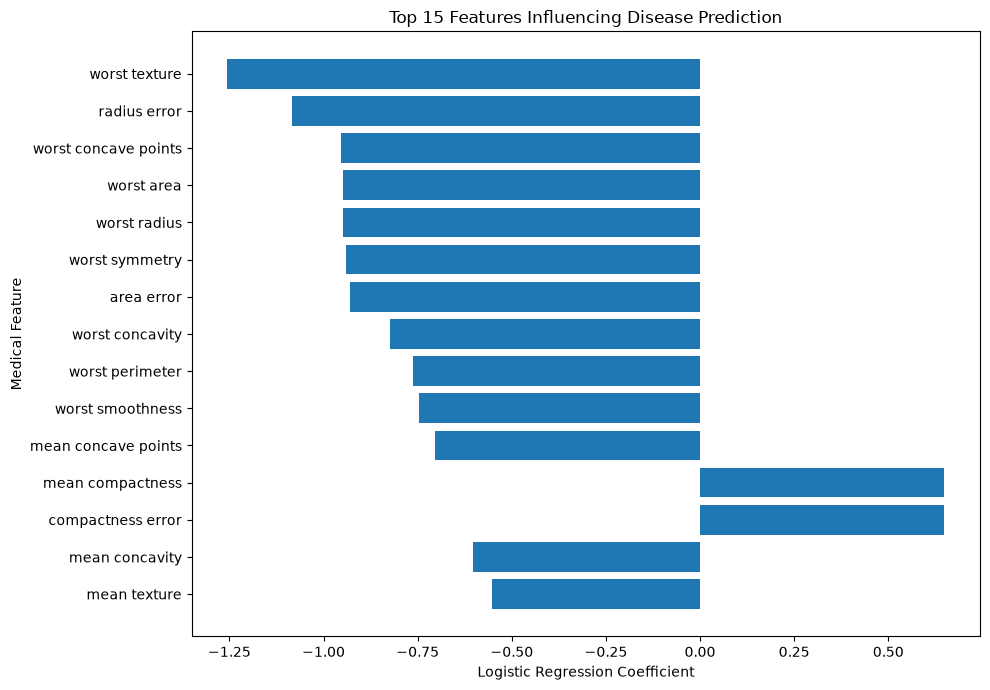

In [26]:
top_features = feature_importance.head(15).sort_values(
    by="Absolute Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Medical Feature")
plt.title("Top 15 Features Influencing Disease Prediction")

plt.tight_layout()
plt.show()

In [27]:
print("Top 10 Important Features:")
print(
    feature_importance[
        ["Feature", "Coefficient", "Absolute Importance"]
    ].head(10).to_string(index=False)
)

Top 10 Important Features:
             Feature  Coefficient  Absolute Importance
       worst texture    -1.255088             1.255088
        radius error    -1.082965             1.082965
worst concave points    -0.953686             0.953686
          worst area    -0.947756             0.947756
        worst radius    -0.947616             0.947616
      worst symmetry    -0.939181             0.939181
          area error    -0.929104             0.929104
     worst concavity    -0.823151             0.823151
     worst perimeter    -0.763220             0.763220
    worst smoothness    -0.746625             0.746625


In [28]:
from sklearn.pipeline import Pipeline

final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

final_model.fit(X_train, y_train)

print("Final model trained successfully! ✅")

Final model trained successfully! ✅


In [29]:
final_predictions = final_model.predict(X_test)

print(
    "Final Model Accuracy:",
    accuracy_score(y_test, final_predictions)
)

Final Model Accuracy: 0.9824561403508771


In [30]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

In [31]:
model_path = "../models/disease_prediction_model.pkl"

joblib.dump(
    final_model,
    model_path
)

print("Disease prediction model saved successfully! ✅")
print("Location:", model_path)

Disease prediction model saved successfully! ✅
Location: ../models/disease_prediction_model.pkl


In [32]:
loaded_model = joblib.load(
    "../models/disease_prediction_model.pkl"
)

print("Saved model loaded successfully! ✅")

Saved model loaded successfully! ✅


In [33]:
loaded_predictions = loaded_model.predict(X_test)

print(
    "Loaded Model Accuracy:",
    accuracy_score(y_test, loaded_predictions)
)

Loaded Model Accuracy: 0.9824561403508771
